In [1]:
# Imports

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Chemins

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: c:\Users\dmmaz\GitHub\brussels-north-social-health-needs-lab


In [3]:
# Chargement de la table produite précédemment

file_path = (
    PROCESSED_DIR
    / "territorial_vulnerability_indicators.csv"
)

vulnerability = pd.read_csv(file_path)

print(vulnerability.shape)
vulnerability.head()

(145, 9)


,territory_code,territory,territory_level,unemployment_rate,unemployment_year,cpas_rate,cpas_year,bim_rate,bim_year
0,1,Grand Place,neighbourhood,15.15,2023,5.06,2023,19.90,2024
1,2,Dansaert,neighbourhood,18.98,2023,5.99,2023,29.31,2024
2,3,Béguinage - Dixmude,neighbourhood,18.60,2023,6.04,2023,28.72,2024
3,4,Martyrs,neighbourhood,13.26,2023,3.60,2023,21.31,2024
4,5,Notre-Dame-aux-Neiges,neighbourhood,15.34,2023,3.40,2023,19.82,2024


In [4]:
# Contrôle structurel

vulnerability.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   territory_code     145 non-null    int64  
 1   territory          145 non-null    str    
 2   territory_level    145 non-null    str    
 3   unemployment_rate  123 non-null    float64
 4   unemployment_year  145 non-null    int64  
 5   cpas_rate          118 non-null    float64
 6   cpas_year          145 non-null    int64  
 7   bim_rate           117 non-null    float64
 8   bim_year           145 non-null    int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 14.1 KB


In [5]:
vulnerability.isna().sum()

territory_code        0
territory             0
territory_level       0
unemployment_rate    22
unemployment_year     0
cpas_rate            27
cpas_year             0
bim_rate             28
bim_year              0
dtype: int64

In [6]:
vulnerability.duplicated(
    subset=["territory_code"]
).sum()

np.int64(0)

In [7]:
# Vérification des années

print(
    "Unemployment years:",
    vulnerability["unemployment_year"].unique()
)

print(
    "CPAS years:",
    vulnerability["cpas_year"].unique()
)

print(
    "BIM years:",
    vulnerability["bim_year"].unique()
)

Unemployment years: [2023]
CPAS years: [2023]
BIM years: [2024]


In [8]:
# Statistiques descriptives

indicator_columns = [
    "unemployment_rate",
    "cpas_rate",
    "bim_rate",
]

vulnerability[indicator_columns].describe().round(2)

,unemployment_rate,cpas_rate,bim_rate
count,123.00,118.00,117.00
mean,15.84,6.04,26.58
std,5.75,3.61,12.89
min,3.06,0.86,4.26
25%,11.62,3.53,17.01
50%,14.83,5.06,24.65
75%,18.98,7.88,36.01
max,31.71,19.02,57.31


## Note : 
A ce stade, nous ne cherchons pas encore à interpréter « le meilleur » ou « le pire » quartier. Nous vérifions surtout :
- La dispersion ;
- Les valeurs extrêmes ;
- Les valeurs manquantes ;
- La cohérence générale.

In [9]:
# Vérifier les valeurs impossibles

for column in indicator_columns:

    invalid = vulnerability[
        (vulnerability[column] < 0)
        | (vulnerability[column] > 100)
    ]

    print(
        column,
        "invalid values:",
        len(invalid)
    )

unemployment_rate invalid values: 0
cpas_rate invalid values: 0
bim_rate invalid values: 0


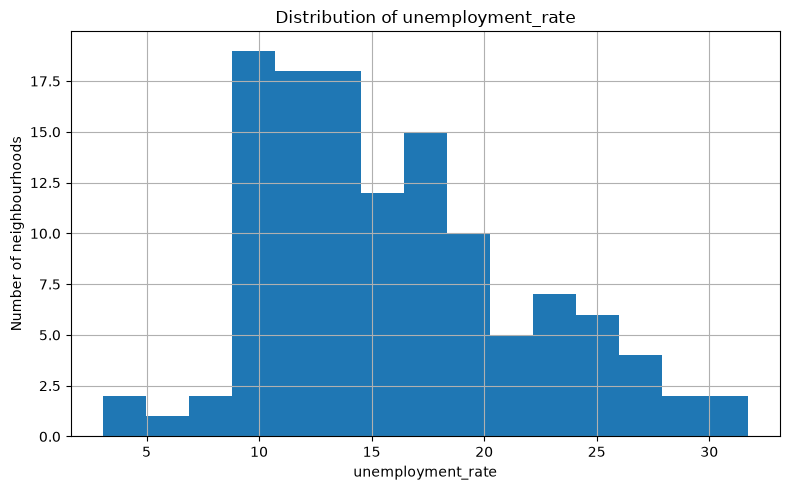

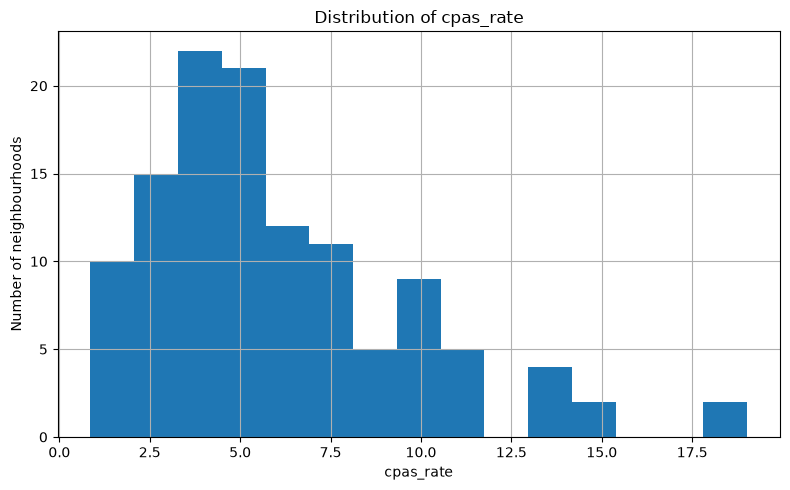

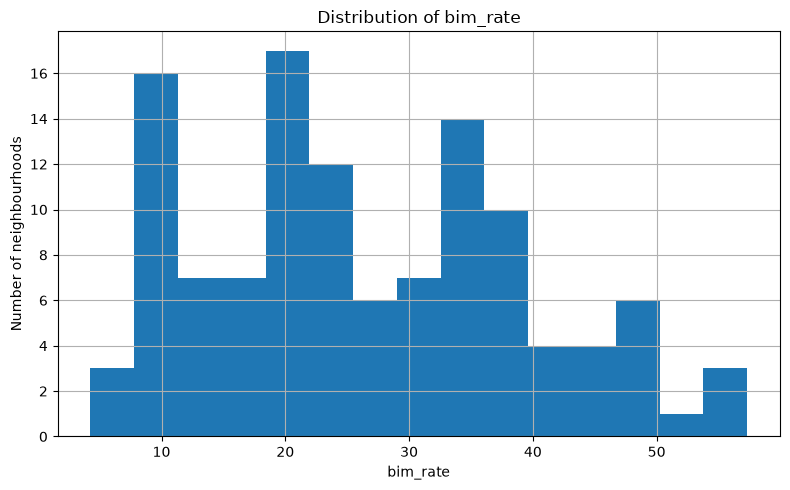

In [10]:
# Graphique des distributions

for column in indicator_columns:

    ax = vulnerability[column].hist(
        bins=15,
        figsize=(8, 5)
    )

    ax.set_title(
        f"Distribution of {column}"
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Number of neighbourhoods")

    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / f"{column}_distribution.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

In [11]:
# Corrélations

correlation_matrix = (
    vulnerability[indicator_columns]
    .corr()
    .round(2)
)

correlation_matrix

,unemployment_rate,cpas_rate,bim_rate
unemployment_rate,1.00,0.87,0.90
cpas_rate,0.87,1.00,0.91
bim_rate,0.90,0.91,1.00


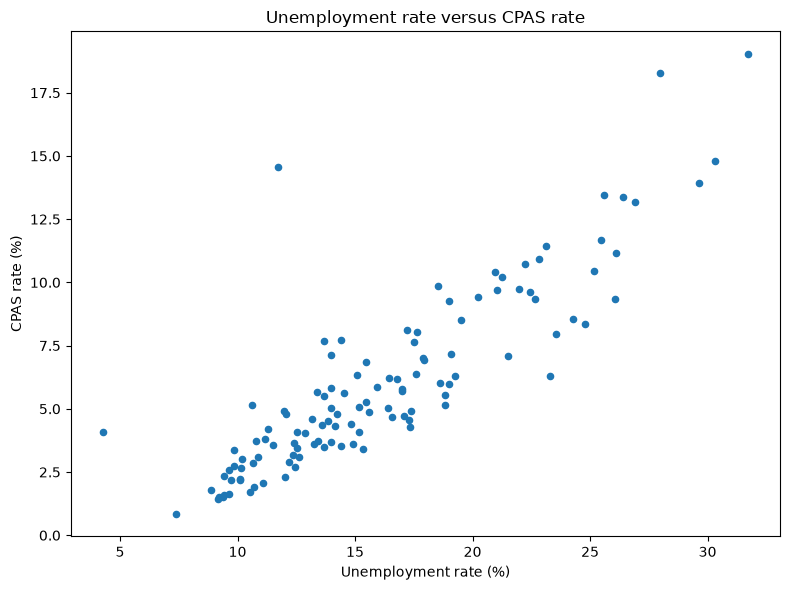

In [20]:
# Scatter plots simples : taux de chomage vs taux de cpas

fig, ax = plt.subplots(figsize=(8, 6))

vulnerability.plot.scatter(
    x="unemployment_rate",
    y="cpas_rate",
    ax=ax
)

ax.set_title("Unemployment rate versus CPAS rate")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("CPAS rate (%)")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "unemployment_vs_cpas.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

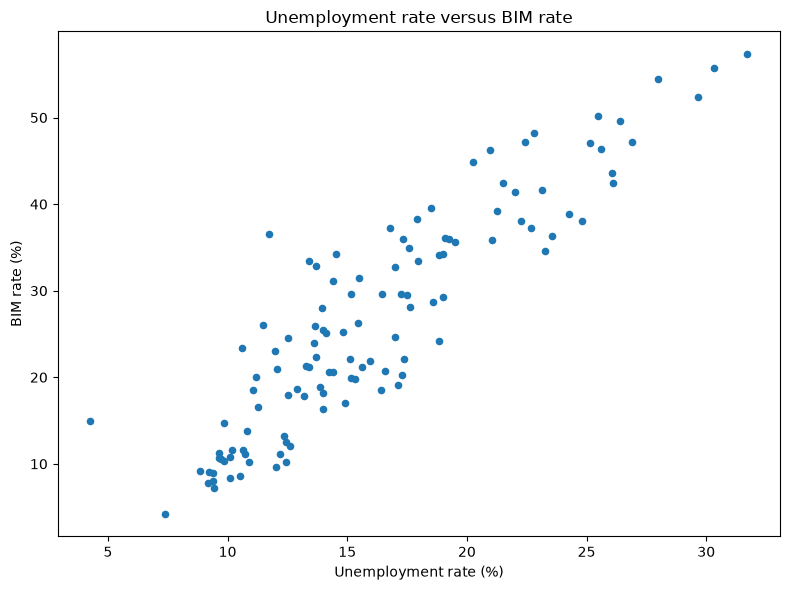

In [21]:
# Scatter plots simples : taux de chomage vs taux de bim

fig, ax = plt.subplots(figsize=(8, 6))

vulnerability.plot.scatter(
    x="unemployment_rate",
    y="bim_rate",
    ax=ax
)

ax.set_title("Unemployment rate versus BIM rate")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("BIM rate (%)")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "unemployment_vs_bim.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

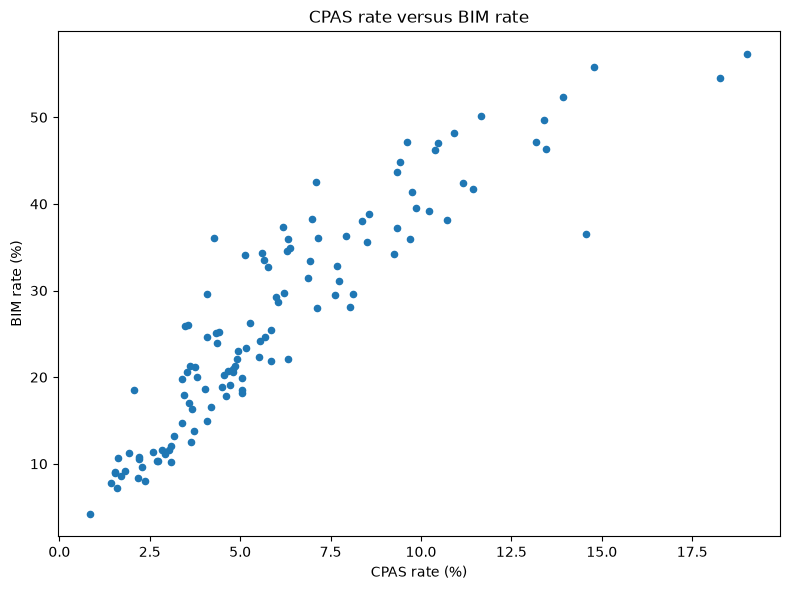

In [22]:
# Scatter plots simples : taux cpas vs taux de bim

fig, ax = plt.subplots(figsize=(8, 6))

vulnerability.plot.scatter(
    x="cpas_rate",
    y="bim_rate",
    ax=ax
)

ax.set_title("CPAS rate versus BIM rate")
ax.set_xlabel("CPAS rate (%)")
ax.set_ylabel("BIM rate (%)")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "cpas_vs_bim.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Interprétation exploratoire. 

Les trois nuages de points mettent en évidence des associations positives nettes entre chômage, recours au CPAS et statut BIM : les quartiers présentant des niveaux élevés pour un indicateur tendent également à afficher des niveaux élevés pour les autres. La relation CPAS–BIM apparaît particulièrement structurée, tandis que la relation chômage–BIM présente une dispersion un peu plus importante. Quelques observations s’écartent de la tendance générale et devront être examinées comme territoires atypiques potentiels, sans qu’elles constituent à ce stade des erreurs de données. Aucune valeur manifestement incohérente n’apparaît visuellement. Ces relations sont descriptives et ne doivent pas être interprétées comme causales.

In [23]:
# Sauvegarde d'une petite synthèse

summary = (
    vulnerability[indicator_columns]
    .describe()
    .round(2)
)

summary.to_csv(
    PROCESSED_DIR
    / "vulnerability_descriptive_statistics.csv"
)